# WR Ensemble - Final

Finalni ensemble notebook koji konsoliduje sve rezultate iz projekta.

## Sastav

Base pool (5 modela, trenirano fresh u ovom notebook-u sa uniformnim recept):
- XGBoost - gradient boosted trees
- LightGBM - alt tree impl.
- ElasticNet - linearni baseline (dodatni diverzitet)
- MLP Hybrid (Huber loss) - najbolji NN tabular, `MODEL_B_PARAMS` iz `WR_MLP_Hybrid`
- MLP Quantile (q50, pinball loss) - ista Hybrid arhitektura ali sa quantile loss-om

Refined training recipe (iz RNN-ere, primenjen uniformno):
- top-40 features iz `selected_features_top40.json`
- sqrt target transform
- sample weights `1 + strength*sqrt(y/mean_y)`, strength=0.6
- temporal split 2015-2021 / 2022-2023 / 2024-2025
- StandardScaler fit na train

## Dve ensemble opcije

Opcija 1 (novi, refined): `{MLP Hybrid, MLP Quantile, LightGBM, ElasticNet}`
- Razlog: najbolji NN tabular modeli + 2 razlicita bias-a (tree + linearni)

Opcija 2 (stari recept, refined training): `{XGBoost, LightGBM, MLP Hybrid}`
- Razlog: reprodukcija sastava iz `WR_Career_RNN_Optuna` koji je dao najbolji rezultat (Test MAE 18.05, R2 0.3384), ali sada sa refined training receptom i novom MLP Hybrid arhitekturom

## 4 strategije kombinovanja (svaka opcija)

1. Simple mean - equal weights
2. Inverse-MAE weighted - tezine proporcionalne 1/val_MAE
3. Constrained LS - `scipy.optimize` minimizuje val MAE uz nenegativne tezine koje sumiraju na 1
4. Ridge stacking - Ridge meta-learner na val predikcijama

## Poredjenje

Finalna tabela ukljucuje:
- Sve base modele (pojedinacno)
- Opcija 1 x 4 strategije
- Opcija 2 x 4 strategije
- Stari ensemble (hardcoded iz `WR_Career_RNN_Optuna`)
- Najbolji pojedinacni modeli (hardcoded: LSTM Improved, MLP Quantile q50)


---
## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, GaussianNoise

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Feature Engineering (canonical pipeline)

In [2]:
df = pd.read_csv('../../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan
    )
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna() & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)
prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (prev_season.notna() & (work_df['season'] != prev_season)).astype(int)
work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])
work_df = work_df.drop(columns=available_roll_cols)

momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = work_df['target_share_lag1'] * work_df['pregame_total']
    interaction_cols.append('target_volume_interaction')
if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    interaction_cols.append('air_yards_expected')
if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = work_df['catch_rate_lag1'] * work_df['targets_lag1']
    interaction_cols.append('expected_receptions')
if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols

target_col = 'receiving_yards'
id_cols = ['receiver_player_id', 'receiver_player_name', 'game_id', 'season', 'week']
model_df = work_df[id_cols + [target_col] + all_feature_columns].copy()
lag1_cols = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_cols].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Dataset: {model_df.shape}, Total features engineered: {len(all_feature_columns)}')


Dataset: (44396, 189), Total features engineered: 184


---
## 3. Split + Top-40 Features + Sample Weights

In [6]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df = model_df[model_df['season'].isin(val_seasons)].copy()
test_df = model_df[model_df['season'].isin(test_seasons)].copy()

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt = val_df['receiving_yards_sqrt'].values
y_test_sqrt = test_df['receiving_yards_sqrt'].values
y_train_orig = train_df['receiving_yards'].values
y_val_orig = val_df['receiving_yards'].values
y_test_orig = test_df['receiving_yards'].values

with open('../../../results/selected_features_top40.json', 'r') as f:
    selected_features = json.load(f)['selected_features']

missing = [f for f in selected_features if f not in train_df.columns]
if missing:
    raise ValueError(f'Missing top-40 features in engineered dataset: {missing}')

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val = scaler.transform(val_df[selected_features].values)
X_test = scaler.transform(test_df[selected_features].values)

mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sw_base = np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)

SW_STRENGTH = 0.6
sw_train = 1.0 + SW_STRENGTH * sw_base

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}  (top-40 selected)')
print(f'Sample weights: [{sw_train.min():.2f}, {sw_train.max():.2f}]  (strength={SW_STRENGTH})')


Train: (29276, 40)  Val: (8921, 40)  Test: (6199, 40)
Features: 40  (top-40 selected)
Sample weights: [1.00, 2.87]  (strength=0.6)


---
## 4. Utility Functions

Helper za evaluaciju (sqrt->orig) i per-bin metriku.


In [5]:
def eval_preds(y_true_orig, y_pred_orig):
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return {'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2)}

def sqrt_to_orig(p_sqrt):
    return np.clip(p_sqrt, 0, None) ** 2

def per_bin_mae(y_true, y_pred, bins=((0,30),(30,80),(80,300))):
    out = {}
    for lo, hi in bins:
        mask = (y_true >= lo) & (y_true < hi)
        if mask.sum() == 0:
            out[f'{lo}-{hi}'] = np.nan
        else:
            out[f'{lo}-{hi}'] = float(mean_absolute_error(y_true[mask], y_pred[mask]))
    return out

print('Utils defined.')


Utils defined.


---
## 5. Train Base Models

Pet base modela. Svi koriste istu X_train/X_val/X_test + sample weights.


### 5.1 XGBoost

In [6]:
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=4, gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', verbosity=0,
)
xgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)], verbose=False)

xgb_val_pred  = sqrt_to_orig(xgb.predict(X_val))
xgb_test_pred = sqrt_to_orig(xgb.predict(X_test))
xgb_val_metrics  = eval_preds(y_val_orig,  xgb_val_pred)
xgb_test_metrics = eval_preds(y_test_orig, xgb_test_pred)
print(f'XGBoost  ({time.time()-t0:.0f}s)  val MAE={xgb_val_metrics["MAE"]:.2f}  test MAE={xgb_test_metrics["MAE"]:.2f}  test R2={xgb_test_metrics["R2"]:.4f}')


XGBoost  (8s)  val MAE=18.17  test MAE=18.09  test R2=0.3148


### 5.2 LightGBM

In [7]:
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=1000, num_leaves=63, learning_rate=0.03,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=SEED, verbosity=-1,
)
lgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)])

lgb_val_pred  = sqrt_to_orig(lgb.predict(X_val))
lgb_test_pred = sqrt_to_orig(lgb.predict(X_test))
lgb_val_metrics  = eval_preds(y_val_orig,  lgb_val_pred)
lgb_test_metrics = eval_preds(y_test_orig, lgb_test_pred)
print(f'LightGBM ({time.time()-t0:.0f}s)  val MAE={lgb_val_metrics["MAE"]:.2f}  test MAE={lgb_test_metrics["MAE"]:.2f}  test R2={lgb_test_metrics["R2"]:.4f}')


LightGBM (11s)  val MAE=18.20  test MAE=18.11  test R2=0.3061


### 5.3 ElasticNet

In [8]:
t0 = time.time()
enet = ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=20000, random_state=SEED)
enet.fit(X_train, y_train_sqrt, sample_weight=sw_train)

enet_val_pred  = sqrt_to_orig(enet.predict(X_val))
enet_test_pred = sqrt_to_orig(enet.predict(X_test))
enet_val_metrics  = eval_preds(y_val_orig,  enet_val_pred)
enet_test_metrics = eval_preds(y_test_orig, enet_test_pred)
print(f'ElasticNet ({time.time()-t0:.0f}s)  val MAE={enet_val_metrics["MAE"]:.2f}  test MAE={enet_test_metrics["MAE"]:.2f}  test R2={enet_test_metrics["R2"]:.4f}')


ElasticNet (1s)  val MAE=18.33  test MAE=18.10  test R2=0.3192


### 5.4 MLP Hybrid (Huber)

Arhitektura iz `WR_MLP_Hybrid` (MODEL_B_PARAMS) + `GaussianNoise(0.15)`.


In [9]:
MODEL_B_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_hybrid_mlp(input_dim, params, loss_fn, noise_stddev=0.15):
    model = keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))
    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))
    model.add(Dense(1))
    opt = optimizers.AdamW(learning_rate=params['lr'], weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=loss_fn, metrics=['mae'])
    return model

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_h = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS, losses.Huber(delta=MODEL_B_PARAMS['huber_delta']))

cb_h = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

hist_h = mlp_h.fit(
    X_train, y_train_sqrt, sample_weight=sw_train,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
    callbacks=cb_h, verbose=0,
)

mlp_h_val_pred  = sqrt_to_orig(mlp_h.predict(X_val,  verbose=0).flatten())
mlp_h_test_pred = sqrt_to_orig(mlp_h.predict(X_test, verbose=0).flatten())
mlp_h_val_metrics  = eval_preds(y_val_orig,  mlp_h_val_pred)
mlp_h_test_metrics = eval_preds(y_test_orig, mlp_h_test_pred)
print(f'MLP Hybrid ({time.time()-t0:.0f}s)  best_ep={int(np.argmin(hist_h.history["val_loss"]))+1}  val MAE={mlp_h_val_metrics["MAE"]:.2f}  test MAE={mlp_h_test_metrics["MAE"]:.2f}  test R2={mlp_h_test_metrics["R2"]:.4f}')



MLP Hybrid (520s)  best_ep=40  val MAE=18.25  test MAE=18.03  test R2=0.3217


### 5.5 MLP Quantile (q50, pinball loss)

Ista Hybrid arhitektura ali sa pinball loss-om za tau=0.5 (medijan). U RNN-u smo kasnije zakljucili
da kvantilna regresija daje najbolji MAE za ovaj dataset (q50 MAE ~17.76 u `WR_MLP_Quantile`).


In [10]:
def pinball_loss_q50(y_true, y_pred):
    e = y_true - y_pred
    return tf.reduce_mean(tf.maximum(0.5 * e, (0.5 - 1.0) * e))

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_q = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS, pinball_loss_q50)

cb_q = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

hist_q = mlp_q.fit(
    X_train, y_train_sqrt, sample_weight=sw_train,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
    callbacks=cb_q, verbose=0,
)

mlp_q_val_pred  = sqrt_to_orig(mlp_q.predict(X_val,  verbose=0).flatten())
mlp_q_test_pred = sqrt_to_orig(mlp_q.predict(X_test, verbose=0).flatten())
mlp_q_val_metrics  = eval_preds(y_val_orig,  mlp_q_val_pred)
mlp_q_test_metrics = eval_preds(y_test_orig, mlp_q_test_pred)
print(f'MLP Quantile q50 ({time.time()-t0:.0f}s)  best_ep={int(np.argmin(hist_q.history["val_loss"]))+1}  val MAE={mlp_q_val_metrics["MAE"]:.2f}  test MAE={mlp_q_test_metrics["MAE"]:.2f}  test R2={mlp_q_test_metrics["R2"]:.4f}')


MLP Quantile q50 (494s)  best_ep=35  val MAE=17.91  test MAE=17.75  test R2=0.3069


---
## 6. Base Model Summary

In [11]:
base_models = {
    'XGBoost':       {'val_pred': xgb_val_pred,   'test_pred': xgb_test_pred,   'val': xgb_val_metrics,   'test': xgb_test_metrics},
    'LightGBM':      {'val_pred': lgb_val_pred,   'test_pred': lgb_test_pred,   'val': lgb_val_metrics,   'test': lgb_test_metrics},
    'ElasticNet':    {'val_pred': enet_val_pred,  'test_pred': enet_test_pred,  'val': enet_val_metrics,  'test': enet_test_metrics},
    'MLP Hybrid':    {'val_pred': mlp_h_val_pred, 'test_pred': mlp_h_test_pred, 'val': mlp_h_val_metrics, 'test': mlp_h_test_metrics},
    'MLP Quantile':  {'val_pred': mlp_q_val_pred, 'test_pred': mlp_q_test_pred, 'val': mlp_q_val_metrics, 'test': mlp_q_test_metrics},
}

base_summary = pd.DataFrame([
    {'Model': name,
     'Val MAE':  round(m['val']['MAE'],  3),
     'Test MAE':  round(m['test']['MAE'],  3),
     'Test RMSE': round(m['test']['RMSE'], 3),
     'Test R2':   round(m['test']['R2'],   4)}
    for name, m in base_models.items()
])
print(base_summary.to_string(index=False))


       Model  Val MAE  Test MAE  Test RMSE  Test R2
     XGBoost   18.165    18.093     25.498   0.3148
    LightGBM   18.203    18.110     25.659   0.3061
  ElasticNet   18.335    18.103     25.416   0.3192
  MLP Hybrid   18.248    18.033     25.369   0.3217
MLP Quantile   17.909    17.750     25.644   0.3069


---
## 7. Ensemble Strategies

Cetiri strategije, svaka se moze primeniti na bilo koji podskup base modela.

1. Simple mean - equal weights
2. Inverse-MAE weighted - w_i = (1/val_MAE_i) / sum(1/val_MAE_j)
3. Constrained LS - scipy minimize nad nenegativnim tezinama koje sumiraju na 1, cilj = val MAE
4. Ridge stacking - Ridge meta-learner treniran na val predikcijama


In [12]:
def ensemble_simple_mean(val_preds, test_preds, y_val, y_test):
    v = np.mean(np.column_stack(val_preds), axis=1)
    t = np.mean(np.column_stack(test_preds), axis=1)
    return {'weights': np.ones(len(val_preds))/len(val_preds),
            'val': eval_preds(y_val, v), 'test': eval_preds(y_test, t),
            'val_pred': v, 'test_pred': t}

def ensemble_inverse_mae(val_preds, test_preds, y_val, y_test, base_val_metrics):
    inv = np.array([1.0/m['MAE'] for m in base_val_metrics])
    w = inv / inv.sum()
    v = np.column_stack(val_preds) @ w
    t = np.column_stack(test_preds) @ w
    return {'weights': w, 'val': eval_preds(y_val, v), 'test': eval_preds(y_test, t),
            'val_pred': v, 'test_pred': t}

def ensemble_constrained_ls(val_preds, test_preds, y_val, y_test):
    P = np.column_stack(val_preds)
    k = P.shape[1]
    def objective(w):
        return mean_absolute_error(y_val, P @ w)
    cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bnds = [(0.0, 1.0)] * k
    w0 = np.ones(k) / k
    res = minimize(objective, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 500, 'ftol': 1e-8})
    w = res.x
    v = P @ w
    t = np.column_stack(test_preds) @ w
    return {'weights': w, 'val': eval_preds(y_val, v), 'test': eval_preds(y_test, t),
            'val_pred': v, 'test_pred': t}

def ensemble_ridge_stack(val_preds, test_preds, y_val, y_test, alpha=1.0):
    Pv = np.column_stack(val_preds)
    Pt = np.column_stack(test_preds)
    meta = Ridge(alpha=alpha, positive=True)
    meta.fit(Pv, y_val)
    v = meta.predict(Pv)
    t = meta.predict(Pt)
    return {'weights': meta.coef_, 'intercept': float(meta.intercept_),
            'val': eval_preds(y_val, v), 'test': eval_preds(y_test, t),
            'val_pred': v, 'test_pred': t}

def run_all_strategies(model_names, base_models, y_val, y_test):
    val_preds  = [base_models[n]['val_pred']  for n in model_names]
    test_preds = [base_models[n]['test_pred'] for n in model_names]
    base_val_metrics = [base_models[n]['val'] for n in model_names]
    return {
        'simple_mean':     ensemble_simple_mean(val_preds, test_preds, y_val, y_test),
        'inverse_mae':     ensemble_inverse_mae(val_preds, test_preds, y_val, y_test, base_val_metrics),
        'constrained_ls':  ensemble_constrained_ls(val_preds, test_preds, y_val, y_test),
        'ridge_stack':     ensemble_ridge_stack(val_preds, test_preds, y_val, y_test),
    }

print('Ensemble functions defined.')


Ensemble functions defined.


---
## 8. Option 1 - New Refined Ensemble

Sastav: `{MLP Hybrid, MLP Quantile, LightGBM, ElasticNet}`


In [13]:
option1_members = ['MLP Hybrid', 'MLP Quantile', 'LightGBM', 'ElasticNet']
opt1 = run_all_strategies(option1_members, base_models, y_val_orig, y_test_orig)

print(f'Option 1 members: {option1_members}')
print()
for strat, r in opt1.items():
    w_str = ', '.join([f'{n}={w:.3f}' for n, w in zip(option1_members, r['weights'])])
    print(f'  {strat:16}  val MAE={r["val"]["MAE"]:.3f}  test MAE={r["test"]["MAE"]:.3f}  R2={r["test"]["R2"]:.4f}   weights: {w_str}')


Option 1 members: ['MLP Hybrid', 'MLP Quantile', 'LightGBM', 'ElasticNet']

  simple_mean       val MAE=17.978  test MAE=17.798  R2=0.3284   weights: MLP Hybrid=0.250, MLP Quantile=0.250, LightGBM=0.250, ElasticNet=0.250
  inverse_mae       val MAE=17.976  test MAE=17.796  R2=0.3283   weights: MLP Hybrid=0.249, MLP Quantile=0.254, LightGBM=0.250, ElasticNet=0.248
  constrained_ls    val MAE=17.869  test MAE=17.708  R2=0.3184   weights: MLP Hybrid=0.000, MLP Quantile=0.704, LightGBM=0.192, ElasticNet=0.104
  ridge_stack       val MAE=18.328  test MAE=18.147  R2=0.3321   weights: MLP Hybrid=0.015, MLP Quantile=0.361, LightGBM=0.301, ElasticNet=0.350


---
## 9. Option 2 - Old Recipe (XGB + LGB + MLP) with Refined Training

Sastav: `{XGBoost, LightGBM, MLP Hybrid}` - isti sastav kao stari ensemble iz `WR_Career_RNN_Optuna`,
ali sa refined training receptom (sqrt target, sample weights strength=0.6, top-40, temporal split 2015-21/22-23/24-25).


In [14]:
option2_members = ['XGBoost', 'LightGBM', 'MLP Hybrid']
opt2 = run_all_strategies(option2_members, base_models, y_val_orig, y_test_orig)

print(f'Option 2 members: {option2_members}')
print()
for strat, r in opt2.items():
    w_str = ', '.join([f'{n}={w:.3f}' for n, w in zip(option2_members, r['weights'])])
    print(f'  {strat:16}  val MAE={r["val"]["MAE"]:.3f}  test MAE={r["test"]["MAE"]:.3f}  R2={r["test"]["R2"]:.4f}   weights: {w_str}')


Option 2 members: ['XGBoost', 'LightGBM', 'MLP Hybrid']

  simple_mean       val MAE=18.069  test MAE=17.927  R2=0.3256   weights: XGBoost=0.333, LightGBM=0.333, MLP Hybrid=0.333
  inverse_mae       val MAE=18.069  test MAE=17.927  R2=0.3256   weights: XGBoost=0.334, LightGBM=0.333, MLP Hybrid=0.333
  constrained_ls    val MAE=18.068  test MAE=17.921  R2=0.3262   weights: XGBoost=0.307, LightGBM=0.327, MLP Hybrid=0.366
  ridge_stack       val MAE=18.377  test MAE=18.220  R2=0.3300   weights: XGBoost=0.386, LightGBM=0.139, MLP Hybrid=0.474


---
## 10. Diagnostics

### 10.1 Residual Correlation Matrix

Ako su svi base modeli jako korelisani (r > 0.9), ensemble nece pomoci. Nizi korelacija = vise
diverziteta = bolji ensemble gain.


Residual correlation matrix (test set):
              XGBoost  LightGBM  ElasticNet  MLP Hybrid  MLP Quantile
XGBoost         1.000     0.987       0.964       0.970         0.973
LightGBM        0.987     1.000       0.964       0.968         0.970
ElasticNet      0.964     0.964       1.000       0.975         0.978
MLP Hybrid      0.970     0.968       0.975       1.000         0.993
MLP Quantile    0.973     0.970       0.978       0.993         1.000


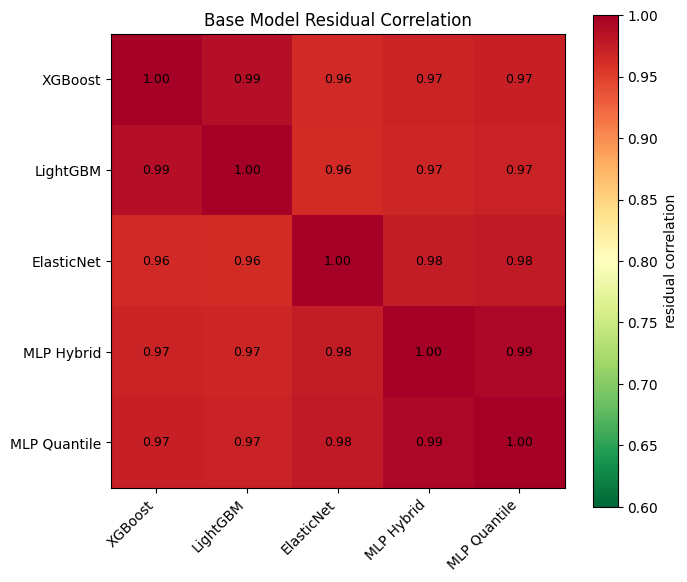

In [15]:
residuals = {name: y_test_orig - m['test_pred'] for name, m in base_models.items()}
res_df = pd.DataFrame(residuals)
corr = res_df.corr()
print('Residual correlation matrix (test set):')
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=0.6, vmax=1.0, cmap='RdYlGn_r')
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='residual correlation')
ax.set_title('Base Model Residual Correlation')
plt.tight_layout()
plt.savefig('../results/ensemble_final_residual_corr.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.2 Per-Bin MAE (Best Base vs Best Ensemble)

In [16]:
best_base_name = base_summary.sort_values('Test MAE').iloc[0]['Model']
best_base_pred = base_models[best_base_name]['test_pred']

all_ens = []
for strat, r in opt1.items():
    all_ens.append(('Opt1_'+strat, r))
for strat, r in opt2.items():
    all_ens.append(('Opt2_'+strat, r))
best_ens_name, best_ens = min(all_ens, key=lambda kv: kv[1]['test']['MAE'])
best_ens_pred = best_ens['test_pred']

bins = [(0,30),(30,60),(60,100),(100,300)]
bb = per_bin_mae(y_test_orig, best_base_pred, bins)
be = per_bin_mae(y_test_orig, best_ens_pred, bins)

bin_df = pd.DataFrame({
    'bin (yards)': [f'{lo}-{hi}' for lo,hi in bins],
    'n': [((y_test_orig>=lo)&(y_test_orig<hi)).sum() for lo,hi in bins],
    f'Best Base ({best_base_name})': [round(bb[f'{lo}-{hi}'],2) for lo,hi in bins],
    f'Best Ensemble ({best_ens_name})': [round(be[f'{lo}-{hi}'],2) for lo,hi in bins],
})
bin_df['Delta'] = (bin_df[f'Best Base ({best_base_name})'] - bin_df[f'Best Ensemble ({best_ens_name})']).round(2)
print(bin_df.to_string(index=False))


bin (yards)    n  Best Base (MLP Quantile)  Best Ensemble (Opt1_constrained_ls)  Delta
       0-30 3837                     11.24                                11.57  -0.33
      30-60 1359                     18.21                                17.70   0.51
     60-100  677                     33.96                                33.06   0.90
    100-300  239                     73.74                                72.53   1.21


---
## 11. Final Comparison Table

Sve zajedno: base modeli + Opcija 1 x 4 + Opcija 2 x 4 + stari ensemble + najbolji pojedinacni.


In [17]:
rows = []

# Base models
for name, m in base_models.items():
    rows.append({
        'Category': 'Base',
        'Model': name,
        'Test MAE':  round(m['test']['MAE'],  3),
        'Test RMSE': round(m['test']['RMSE'], 3),
        'Test R2':   round(m['test']['R2'],   4),
        'Source': 'this notebook',
    })

# Option 1
for strat, r in opt1.items():
    rows.append({
        'Category': 'Ensemble Opt1',
        'Model': f'Opt1 / {strat}',
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
        'Source': 'this notebook',
    })

# Option 2
for strat, r in opt2.items():
    rows.append({
        'Category': 'Ensemble Opt2',
        'Model': f'Opt2 / {strat}',
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
        'Source': 'this notebook',
    })

# Historical references
rows.append({
    'Category': 'Reference',
    'Model': 'OLD Ensemble (XGB+LGB+MLP, grid weights)',
    'Test MAE':  18.05, 'Test RMSE': 25.05, 'Test R2': 0.3384,
    'Source': 'WR_Career_RNN_Optuna',
})
rows.append({
    'Category': 'Reference',
    'Model': 'LSTM Improved (best single RNN)',
    'Test MAE':  18.029, 'Test RMSE': 25.110, 'Test R2': 0.3354,
    'Source': 'WR_RNN_Improved',
})
rows.append({
    'Category': 'Reference',
    'Model': 'GRU Improved (Optuna)',
    'Test MAE':  18.094, 'Test RMSE': 25.164, 'Test R2': 0.3326,
    'Source': 'WR_RNN_Improved_GRU',
})
rows.append({
    'Category': 'Reference',
    'Model': 'MLP Quantile q50 (standalone)',
    'Test MAE':  17.760, 'Test RMSE': 25.600, 'Test R2': 0.3093,
    'Source': 'WR_MLP_Quantile',
})

final_df = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
pd.set_option('display.max_colwidth', None)
print(final_df.to_string(index=False))


     Category                                    Model  Test MAE  Test RMSE  Test R2               Source
Ensemble Opt1                    Opt1 / constrained_ls    17.708     25.430   0.3184        this notebook
         Base                             MLP Quantile    17.750     25.644   0.3069        this notebook
    Reference            MLP Quantile q50 (standalone)    17.760     25.600   0.3093      WR_MLP_Quantile
Ensemble Opt1                       Opt1 / inverse_mae    17.796     25.244   0.3283        this notebook
Ensemble Opt1                       Opt1 / simple_mean    17.798     25.243   0.3284        this notebook
Ensemble Opt2                    Opt2 / constrained_ls    17.921     25.285   0.3262        this notebook
Ensemble Opt2                       Opt2 / inverse_mae    17.927     25.295   0.3256        this notebook
Ensemble Opt2                       Opt2 / simple_mean    17.927     25.295   0.3256        this notebook
    Reference          LSTM Improved (best sin

### 11.1 Bar Chart - All Models Sorted by Test MAE

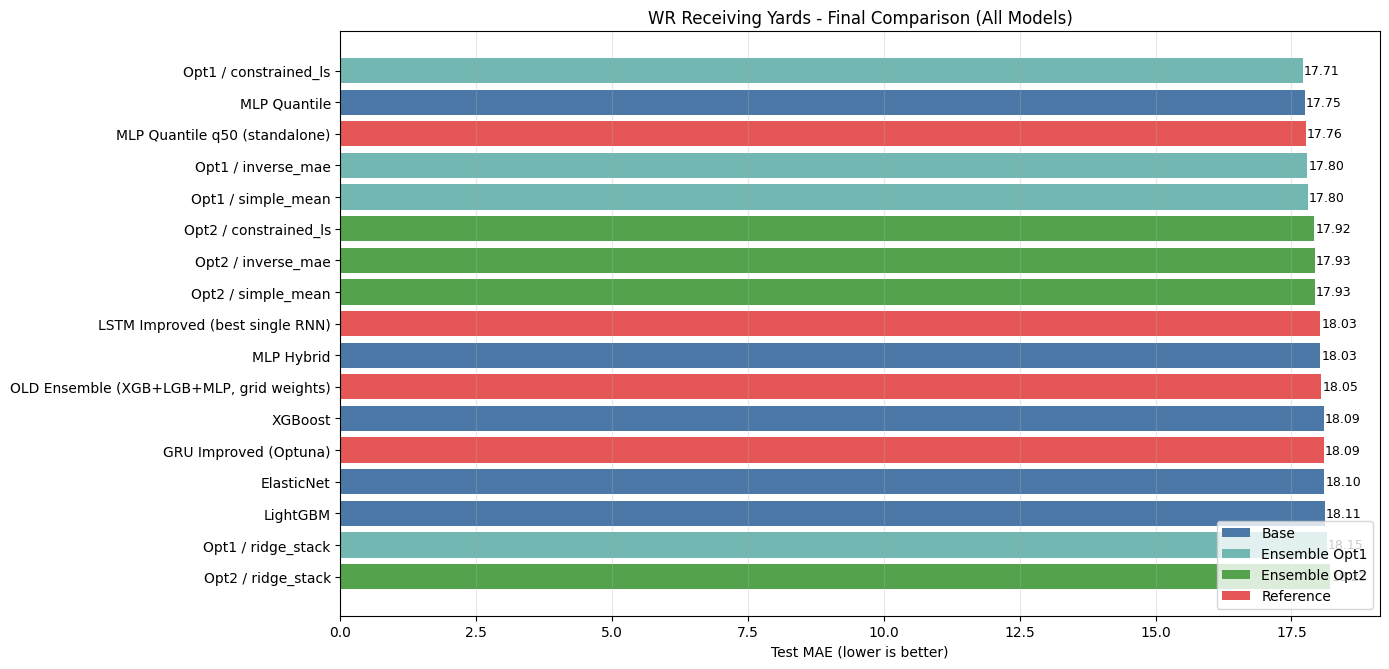

In [18]:
plot_df = final_df.copy()
colors_map = {'Base': '#4C78A8', 'Ensemble Opt1': '#72B7B2', 'Ensemble Opt2': '#54A24B', 'Reference': '#E45756'}
bar_colors = [colors_map[c] for c in plot_df['Category']]

fig, ax = plt.subplots(figsize=(14, max(6, 0.4*len(plot_df))))
y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df['Test MAE'], color=bar_colors)
ax.set_yticks(y_pos); ax.set_yticklabels(plot_df['Model'])
ax.invert_yaxis()
ax.set_xlabel('Test MAE (lower is better)')
ax.set_title('WR Receiving Yards - Final Comparison (All Models)')
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l,c in colors_map.items()]
ax.legend(handles=legend_elems, loc='lower right')

# Value labels
for i, v in enumerate(plot_df['Test MAE']):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/ensemble_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. New vs Old Ensemble Head-to-Head

Fokusirana tabela: Novi ensemble-i (najbolje strategije Opcije 1 i 2) vs stari ensemble.


In [19]:
best_opt1_strat = min(opt1.items(), key=lambda kv: kv[1]['test']['MAE'])
best_opt2_strat = min(opt2.items(), key=lambda kv: kv[1]['test']['MAE'])

h2h = pd.DataFrame([
    {
        'Ensemble': f'Opt1 best ({best_opt1_strat[0]})',
        'Members': ', '.join(option1_members),
        'Test MAE':  round(best_opt1_strat[1]['test']['MAE'], 3),
        'Test RMSE': round(best_opt1_strat[1]['test']['RMSE'], 3),
        'Test R2':   round(best_opt1_strat[1]['test']['R2'], 4),
    },
    {
        'Ensemble': f'Opt2 best ({best_opt2_strat[0]})',
        'Members': ', '.join(option2_members),
        'Test MAE':  round(best_opt2_strat[1]['test']['MAE'], 3),
        'Test RMSE': round(best_opt2_strat[1]['test']['RMSE'], 3),
        'Test R2':   round(best_opt2_strat[1]['test']['R2'], 4),
    },
    {
        'Ensemble': 'OLD (reference)',
        'Members': 'XGBoost, LightGBM, MLP (old)',
        'Test MAE':  18.05,
        'Test RMSE': 25.05,
        'Test R2':   0.3384,
    },
])
print(h2h.to_string(index=False))

# Delta vs old
old_mae, old_rmse, old_r2 = 18.05, 25.05, 0.3384
print()
print('Delta vs OLD ensemble (negative = better):')
for i, row in h2h.iloc[:2].iterrows():
    d_mae = row['Test MAE'] - old_mae
    d_rmse = row['Test RMSE'] - old_rmse
    d_r2 = row['Test R2'] - old_r2
    print(f'  {row["Ensemble"]:35}  dMAE={d_mae:+.3f}  dRMSE={d_rmse:+.3f}  dR2={d_r2:+.4f}')


                  Ensemble                                        Members  Test MAE  Test RMSE  Test R2
Opt1 best (constrained_ls) MLP Hybrid, MLP Quantile, LightGBM, ElasticNet    17.708     25.430   0.3184
Opt2 best (constrained_ls)                  XGBoost, LightGBM, MLP Hybrid    17.921     25.285   0.3262
           OLD (reference)                   XGBoost, LightGBM, MLP (old)    18.050     25.050   0.3384

Delta vs OLD ensemble (negative = better):
  Opt1 best (constrained_ls)           dMAE=-0.342  dRMSE=+0.380  dR2=-0.0200
  Opt2 best (constrained_ls)           dMAE=-0.129  dRMSE=+0.235  dR2=-0.0122


---
## 13. Save Results

In [20]:
def clean_ens(ens_dict):
    return {
        strat: {
            'weights': [float(w) for w in r['weights']],
            'val': r['val'],
            'test': r['test'],
        } for strat, r in ens_dict.items()
    }

output = {
    'config': {
        'seed': SEED, 'sw_strength': SW_STRENGTH,
        'train_seasons': train_seasons, 'val_seasons': val_seasons, 'test_seasons': test_seasons,
        'n_features': X_train.shape[1],
        'mlp_params': MODEL_B_PARAMS,
    },
    'base_models': {
        name: {'val': m['val'], 'test': m['test']}
        for name, m in base_models.items()
    },
    'option1': {
        'members': option1_members,
        'strategies': clean_ens(opt1),
    },
    'option2': {
        'members': option2_members,
        'strategies': clean_ens(opt2),
    },
    'residual_corr': corr.round(4).to_dict(),
    'references': {
        'old_ensemble': {'MAE': 18.05, 'RMSE': 25.05, 'R2': 0.3384, 'source': 'WR_Career_RNN_Optuna'},
        'lstm_improved': {'MAE': 18.029, 'RMSE': 25.110, 'R2': 0.3354, 'source': 'WR_RNN_Improved'},
        'gru_improved':  {'MAE': 18.094, 'RMSE': 25.164, 'R2': 0.3326, 'source': 'WR_RNN_Improved_GRU'},
        'mlp_quantile':  {'MAE': 17.760, 'RMSE': 25.600, 'R2': 0.3093, 'source': 'WR_MLP_Quantile'},
    },
}

with open('../results/ensemble_final_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

final_df.to_csv('../results/ensemble_final_comparison.csv', index=False)
h2h.to_csv('../results/ensemble_final_h2h.csv', index=False)

print('Saved:')
print('  results/ensemble_final_results.json')
print('  results/ensemble_final_comparison.csv')
print('  results/ensemble_final_h2h.csv')
print('  results/ensemble_final_comparison.png')
print('  results/ensemble_final_residual_corr.png')


Saved:
  results/ensemble_final_results.json
  results/ensemble_final_comparison.csv
  results/ensemble_final_h2h.csv
  results/ensemble_final_comparison.png
  results/ensemble_final_residual_corr.png


---
## 14. Diskusija i Zakljucak

Sta je urađeno:
- 5 base modela (XGB, LGB, ElasticNet, MLP Hybrid, MLP Quantile) trenirano sa uniformnim refined receptom
- 2 ensemble opcije:
  - Opcija 1 (novi): najbolji NN tabular + LGB + ElasticNet
  - Opcija 2 (reprodukcija starog): XGB + LGB + MLP Hybrid
- 4 strategije kombinovanja svakom opcijom: mean, inverse-MAE, constrained LS, Ridge stacking
- Poredjenje sa starim ensemble-om iz `WR_Career_RNN_Optuna` (hardcoded reference)

Sta gledati u tabelama gore:
- Da li neki Ensemble Opt1/Opt2 dolazi ispod stare reference MAE=18.05?
- Da li Opt1 (sa Quantile MLP) pobedjuje Opt2 (stari recept)?
- Koja strategija kombinovanja je najbolja za koju opciju?
- Residual correlation matrix: da li MLP Quantile donosi diverzitet (ako su njegovi reziduali najmanje korelisani sa ostalima, dodao je vrednost)

Najvaznije za odbranu:
- Ako Opt1 > Opt2 > Old -> novi recept i Quantile MLP su stvarno doneli napredak
- Ako Opt2 ~ Old -> potvrda da je stari sastav bio dobar i da napredak dolazi iz Quantile-a (Opt1)
- Ako Old najbolji -> iskreno priznati da napredak u NN arhitekturi ne pomaze bez novih base modela
